# CSS Decoding Expanded Bivariate Bicycle Codes

This notebook loads bivariate bicycle CSS codes from `generator_matrices/bivariate_bicycle`, ensures expanded `Mqq` and `Mpp` lattice generators exist, and decodes one CSS sector using the same pattern as the surface-code CSS example.

In [1]:
using LinearAlgebra
using LatticeDecoder
using NPZ
using Plots
using Random
using SparseArrays
Random.seed!(5);

Find the BB input directory and expand any missing files. The constructor writes `Mqq` and `Mpp` while preserving the original `hx`, `hz`, `lx`, and `lz` arrays.

In [10]:
function balance_row_weights!(mat::SparseMatrixCSC{Int64, Int64})
    for i in 1:size(mat, 1)
        row = mat[i, :]
        num_nzvals = count(!iszero, row)
        if num_nzvals == 1
            nz_idx = row.nzind[1]
            # find the row that has a 1 in the same column
            for j in 1:size(mat, 1)
                if j == i
                    continue
                end
                if mat[j, nz_idx] == 1
                    row2 = mat[j, :]
                    mat[i, :] .= row2 .- row
                    break
                end
            end
        end
    end
end


function load_code(code_name::String, balance_weights::Bool = false, reduced_basis::Bool=true)

    if reduced_basis
        p = parse(Int, code_name[end])
        code_data = npzread("../generator_matrices/bivariate_bicycle/expanded/$(code_name)_expanded.npz")

        if balance_weights
            H = code_data["Mqq"]
            H_CSC = sparse(H)
            balance_row_weights!(H_CSC)
            Mqq = Matrix(H_CSC / sqrt(p))

            H = code_data["Mpp"]
            H_CSC = sparse(H)
            balance_row_weights!(H_CSC)
            Mpp = Matrix(H_CSC / sqrt(p))

            println(log2(abs(det(Mqq))) + log2(abs(det(Mpp))))
            return Mqq, Mpp
        end

        Mqq = code_data["Mqq"] / sqrt(p)
        Mpp = code_data["Mpp"] / sqrt(p)

        println(log2(abs(det(Mqq))) + log2(abs(det(Mpp))))
        return Mqq, Mpp
    
    else
        p = parse(Int, code_name[end])
        code_data = npzread("../generator_matrices/bivariate_bicycle/expanded/$(code_name)_overcomplete.npz")
        Mqq = code_data["Mqq"] / sqrt(p);
        Mpp = code_data["Mpp"] / sqrt(p);
        return Mqq, Mpp
    end

end

Mqq, Mpp = load_code("48_4_7_p2", true);
Mqq




3.9999999999999902


48×48 Matrix{Float64}:
 0.0       0.0       0.0       0.0       …   0.0       0.0        0.0
 0.0       0.0       0.0       0.0           0.0       0.0        0.0
 0.0       0.707107  0.0       0.0           0.0       0.0        0.0
 0.0       0.0       0.707107  0.0           0.707107  0.0        0.707107
 0.0       0.0       0.0       0.0           0.0       0.0        0.0
 0.0       0.0       0.0       0.0       …   0.0       0.0        0.0
 0.0       0.0       0.0       0.707107      0.0       0.0        0.0
 0.0       0.0       0.0       0.0           0.0       0.0        0.0
 0.0       0.707107  0.0       0.0           0.0       0.707107   0.707107
 0.0       0.0       0.0       0.0           0.0       0.0        0.0
 ⋮                                       ⋱   ⋮                   
 0.0       0.0       0.707107  0.0           0.707107  0.0        0.707107
 0.0       0.707107  0.0       0.0       …   0.0       0.0        0.0
 0.0       0.0       0.0       0.0           0.0       0

## Decoding Sweep

This small sweep is intentionally tiny so the notebook stays interactive. Increase `samples_per_point` for smoother curves.

In [26]:
function is_not_logical_error(logical_check, residual; atol = 1e-5)
    logical_coordinates = logical_check' * residual
    return all(abs(x - round(x)) < atol for x in logical_coordinates)
end

function bb_decode_fails(H, G, logical_check, noise_std,
    decoder,
    local_search_decoder,
    local_search = true,
)

    error_vector = sample_error(noise_std, size(H, 2))
    received = copy(error_vector)
    tanner_graph = initialize_tanner_graph(H)


    bp_estimate = run_decoder!(decoder, received)
    decoded_integer_correction = hard_decision(bp_estimate, H)

    if local_search
        λ = abs.(H * bp_estimate) .% 1.0
        local_search!(received, λ, decoded_integer_correction, local_search_decoder)
    end

    correction = received - G * decoded_integer_correction
    residual = error_vector - correction

    return !is_not_logical_error(logical_check, residual)
end


codes = ["30_4_5_p2", "48_4_7_p2"]
balance_weights = true
basis = "X"
local_search = true



sigmas = collect(range(0.25, 0.65; length = 7)) ./ sqrt(2 * pi)
samples_per_point = 5000
failure_rates = Dict{String, Vector{Float64}}()

for code in codes
    Mqq, Mpp = load_code(code, balance_weights)

    
    if basis == "X"
        H = Mqq
        G = inv(Mpp)
        logical_check = inv(Mqq)
    elseif basis == "Z"
        H = Mpp
        G = -inv(Mqq)
        logical_check = inv(Mpp)
    end
    
    tg = initialize_tanner_graph(H)
    rates = Float64[]
    
    order = [2, 2, 1, 1, 1]
    local_search_decoder = LocalSearch(length(order), G, order, true, false, false)
    for sigma in sigmas
        decoder = LDLCDecoder(tg; schedule = :serial, algorithm = :lsd, sigma = sigma)
        failures = count(_ -> bb_decode_fails(H, G, logical_check, sigma, decoder, local_search_decoder, local_search), 1:samples_per_point)
        push!(rates, failures / samples_per_point)
    end

    failure_rates[code] = rates
end

failure_rates

Dict{String, Vector{Float64}} with 2 entries:
  "48_4_7_p2" => [0.0, 0.0004, 0.0092, 0.0984, 0.3238, 0.62, 0.8124]
  "30_4_5_p2" => [0.0002, 0.0018, 0.0214, 0.098, 0.2358, 0.404, 0.598]

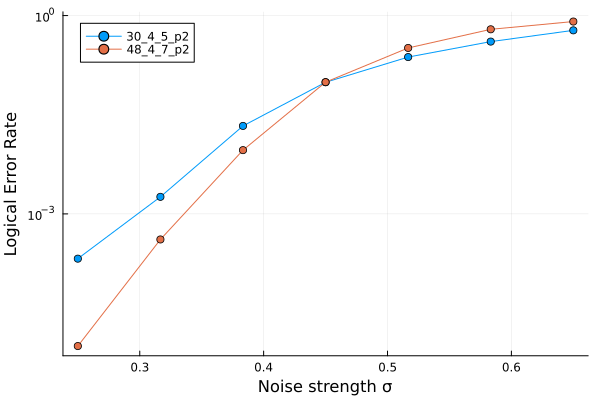

In [32]:


p = plot(
    xlabel = "Noise strength σ",
    ylabel = "Logical Error Rate",
    legend = :topleft,
    yscale = :log10,
)

for code in codes
    plot!(p, sigmas * sqrt(2 * pi), failure_rates[code] .+ 1e-5; marker = :circle, label = code)
end

p